In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pickle
import os.path

import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from scipy.interpolate import griddata
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, RBFInterpolator

In [2]:
def remove_no_flow_temp_points(well_name, df, min_flow=0., trust_init=True): 
    #create subset for one well
    well_df = df[df.name == well_name]
    well_df['flow'] = well_df.area_sk

    #define 'flow' column where flow measurements are available
    well_df.loc[well_df["typ_sk"] == 1, "flow"] = 1
    well_df.loc[((well_df["typ_sk"] == 1) & (well_df["val"] <= min_flow)), "flow"] = 0
    if trust_init==False: 
        well_df.iloc[0, -1] = 0 #do not trust the first values  
    else: 
        well_df.iloc[0, -1] = 1 #trust the first values 

    #interpolate for rest of measurements
    for i in range(well_df.shape[0]-1):
        if (well_df.iloc[i, -1] == 1) & (well_df.iloc[i+1, -1] != 1) & (well_df.iloc[i+1, -1] != 0): 
            well_df.iloc[i+1, -1] = 1
        elif (well_df.iloc[i, -1] == 0) & (well_df.iloc[i+1, -1] != 1) & (well_df.iloc[i+1, -1] != 0): 
            well_df.iloc[i+1, -1] = 0

    #set T values to 0 where 'flow' == 0
    well_df.loc[well_df["typ_sk"] == 2, 'val'] = well_df["flow"] * well_df['val']
    print(f'Removed {sum(well_df.loc[well_df["typ_sk"] == 2, 'val']==0)} temp. datapoints from well {well_name}')
    #plt.plot(well_df.ts[well_df.typ_sk==2], well_df.val[well_df.typ_sk==2]);

    #update original dataframe (doesn't work with nan)
    df.update(well_df)

    #replace T=0ºC to nan
    df[df['typ_sk']==2] = df[df['typ_sk']==2].replace(0, np.nan)

    return df

In [3]:
print('loading files...')
df_type_def = pickle.load(open("data_type_def.pkl",'rb'))
raw_df = pickle.load(open("raw_data_detailed_Reykir_Reykjahlid.pkl",'rb'))
print('assembling dfframe...')
df = pd.DataFrame(raw_df)
print('cleaning up ...')
#sort by time (ts) to prevent jumping in line plot
df = df.sort_values(by='ts', ascending=True)

df

loading files...


assembling dfframe...
cleaning up ...


,t0,t1,ts,loc_sk,mod_sk,typ_sk,val,name,area,area_sk
966,1971-01-14 18:00:00,1971-01-14 18:00:01,1971-01-14 18:00:00,5,1,2,85.000000,MG-03,Reykir,3
4927,1971-02-18 20:00:00,1971-02-18 20:00:01,1971-02-18 20:00:00,8,1,2,87.000000,MG-06,Reykir,3
4928,1971-02-25 09:45:00,1971-02-25 09:45:01,1971-02-25 09:45:00,8,1,2,82.000000,MG-06,Reykir,3
4929,1971-02-28 18:10:00,1971-02-28 18:10:01,1971-02-28 18:10:00,8,1,2,82.000000,MG-06,Reykir,3
967,1971-03-03 17:30:00,1971-03-03 17:30:01,1971-03-03 17:30:00,5,1,2,79.000000,MG-03,Reykir,3
...,...,...,...,...,...,...,...,...,...,...
2853158,2024-12-31 00:00:00,2024-12-31 01:00:00,2024-12-31 00:00:00,35,1,5,-19.317839,MG-33,Reykjahlíð,4
3223576,2024-12-31 00:00:00,2024-12-31 01:00:00,2024-12-31 00:00:00,10,1,1,32.163320,MG-08,Reykir,3
3190675,2024-12-31 00:00:00,2024-12-31 01:00:00,2024-12-31 00:00:00,8,1,1,36.132773,MG-06,Reykir,3
2885805,2024-12-31 00:00:00,2024-12-31 01:00:00,2024-12-31 00:00:00,36,1,1,99.999313,MG-34,Reykjahlíð,4


if os.path.isfile('clean_data.csv'): 
    print('found clean file')
    data = pd.read_csv('clean_data.csv')
else: 
    print('loading files...')
    data_type_def = pickle.load(open("data_type_def.pkl",'rb'))
    raw_data = pickle.load(open("raw_data_detailed_Reykir_Reykjahlid.pkl",'rb'))
    print('assembling dataframe...')
    data = pd.DataFrame(raw_data)
    print('cleaning up ...')
    #sort by time (ts) to prevent jumping in line plot
    data = data.sort_values(by='ts', ascending=True)
    #remove temp measurements when no flow:
    for well in data.name.unique():
        data = remove_no_flow_temp_points(well, df=data)
    #export clean data to save time later
    data.to_csv('clean_data.csv')
    print('done')

data

In [4]:
#Check values for same timestep ['ts'] well ['name'] where flow ['typ_sk'==2] is 0 
df.loc[(df.duplicated(subset=['ts', 'name'], keep=False)) & (df['typ_sk']==2) & (df['val']<10)]

,t0,t1,ts,loc_sk,mod_sk,typ_sk,val,name,area,area_sk


In [5]:
#loc_sk is a numerical code for (well) name
print(len((df.loc_sk == 4) & (df.name == 'MG-01')) == len(df.loc_sk == 4) == len(df.name == 'MG-01'))

#t0 and ts are always the same (?)
print(len(df.t0 == df.ts) == len(df))

#area_sk is a numerical code for area name 
print(len((df.area == 'Reykir') & (df.area_sk == 3)) == len(df.area == 'Reykir') == len(df.area_sk == 3))

#mod_sk is always 1 
print(df.mod_sk.unique())

#data types are: {1: flow rate (l/s), 2: temperature (ºC), 5: water level (masl)}
print(df.typ_sk.unique())

True
True
True
[1]
[2 1 5]


In [6]:
def plot_well_data(well_name):
    well_pressure = df[(df.typ_sk==1) & (df.name==well_name)]
    well_temp = df[(df.typ_sk==2) & (df.name==well_name)]
    well_level = df[(df.typ_sk==5) & (df.name==well_name)]

    fig, (ax1, ax2, ax3) = plt.subplots(3,1, sharex=True, figsize=(20, 12))
    ax1.set_title(f'Production data: {well_name}')

    #ax1.plot(df.ts[(df.typ_sk==1) & (df.name==well_name)], df.val[(df.typ_sk==1) & (df.name==well_name)], 
    #            c='tab:blue', linewidth=0.5)
    ax1.plot(well_pressure.ts, well_pressure.groupby(well_pressure.ts.dt.year)['val'].transform('mean'), 
                c='tab:blue', linewidth=3, label='Yearly average')
    ax1.plot(well_pressure.ts, well_pressure.groupby([well_pressure.ts.dt.year, well_pressure.ts.dt.month])['val'].transform('mean'), 
                c='tab:blue', linewidth=0.5, label='Yearly average')
    ax1.set_ylabel('Flow rate [l/s]')
    ax1.legend()

    ax2.plot(well_temp.ts, well_temp.val, 
                c='tab:red', linewidth=0.5)
    ax2.plot(well_temp.ts, well_temp.groupby(well_temp.ts.dt.year)['val'].transform('mean'), 
                c='tab:red', linewidth=3)
    ax2.set_ylabel('Temperature [ºC]')

    ax3.plot(well_level.ts, well_level.val, 
                c='tab:green', linewidth=0.5)
    ax3.plot(well_level.ts, well_level.groupby(well_level.ts.dt.year)['val'].transform('mean'), 
                c='tab:green', linewidth=3)
    ax3.set_ylabel('Water level [masl]')
    ax3.set_xlabel('Time');

def plot_field_data(field_name):
    field_pressure = df[(df.typ_sk==1) & (df.area==field_name)].groupby([df.ts.dt.year, df.ts.dt.month, df.name])['val'].mean()
    field_temp = df[(df.typ_sk==2) & (df.area==field_name)].groupby([df.ts.dt.year, df.ts.dt.month, df.name])['val'].mean()
    field_level = df[(df.typ_sk==5) & (df.area==field_name)].groupby([df.ts.dt.year, df.ts.dt.month, df.name])['val'].mean()

    monthly_pressure = field_pressure.groupby(level=[0, 1]).sum()
    annual_pressure = monthly_pressure.groupby(level=[0]).mean()
    monthly_pressure.index = pd.to_datetime(pd.DataFrame(monthly_pressure.index.tolist(), columns=['year', 'month']).assign(day=1))
    annual_pressure.index = pd.to_datetime(pd.DataFrame(annual_pressure.index.tolist(), columns=['year']).assign(month=1, day=1))

    monthly_temp = field_temp.groupby(level=[0, 1]).mean()
    annual_temp = monthly_temp.groupby(level=[0]).mean()
    monthly_temp.index = pd.to_datetime(pd.DataFrame(monthly_temp.index.tolist(), columns=['year', 'month']).assign(day=1))
    annual_temp.index = pd.to_datetime(pd.DataFrame(annual_temp.index.tolist(), columns=['year']).assign(month=1, day=1))

    monthly_level = field_level.groupby(level=[0, 1]).mean()
    annual_level = monthly_level.groupby(level=[0]).mean()
    monthly_level.index = pd.to_datetime(pd.DataFrame(monthly_level.index.tolist(), columns=['year', 'month']).assign(day=1))
    annual_level.index = pd.to_datetime(pd.DataFrame(annual_level.index.tolist(), columns=['year']).assign(month=1, day=1))

    
    fig, (ax1, ax2, ax3) = plt.subplots(3,1, sharex=True, figsize=(20, 12))
    ax1.set_title(f'Production data: {field_name}')

    ax1.plot(annual_pressure.index, annual_pressure.values,
                c='tab:blue', linewidth=3, label='Yearly average')
    ax1.plot(monthly_pressure.index, monthly_pressure.values,  
                c='tab:blue', linewidth=0.5, label='Monthly average')
    ax1.set_ylabel('Flow rate [l/s]')
    ax1.legend()

    ax2.plot(annual_temp.index, annual_temp.values, 
                c='tab:red', linewidth=3)
    ax2.plot(monthly_temp.index, monthly_temp.values,  
                c='tab:red', linewidth=0.5)
    ax2.set_ylabel('Temperature [ºC]')

    ax3.plot(annual_level.index, annual_level.values, 
                c='tab:green', linewidth=3)
    ax3.plot(monthly_level.index, monthly_level.values,  
                c='tab:green', linewidth=0.5)
    ax3.set_ylabel('Water level [masl]')
    ax3.set_xlabel('Time');

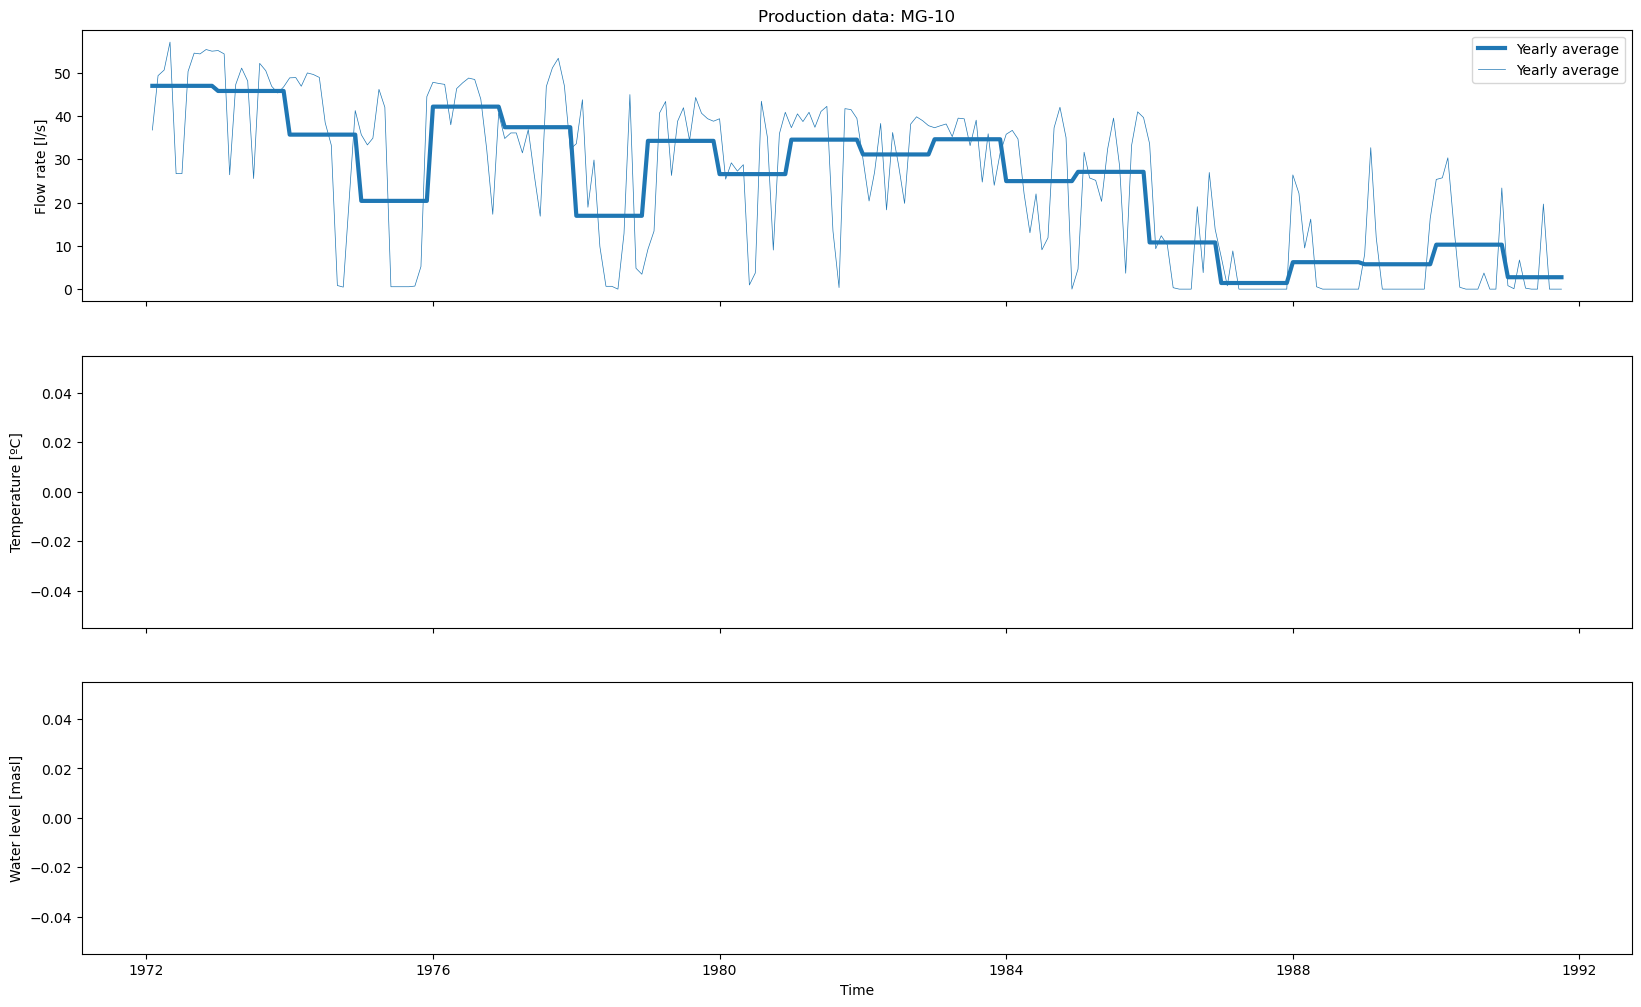

In [7]:
plot_well_data('MG-10')

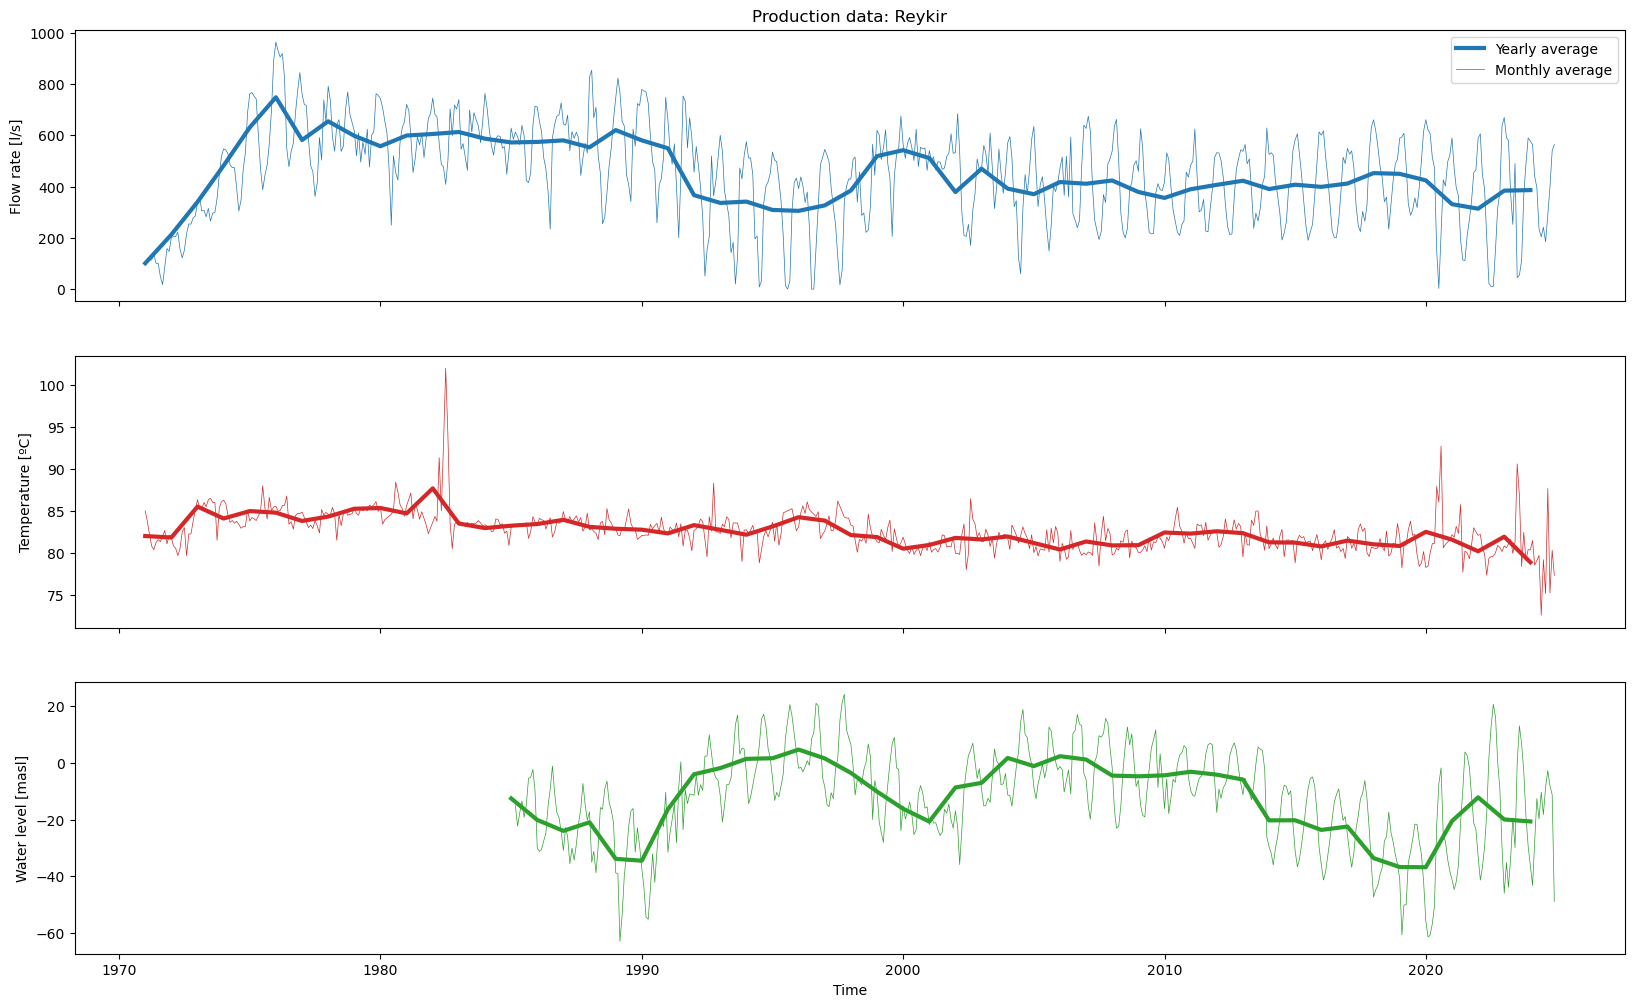

In [8]:
plot_field_data('Reykir')

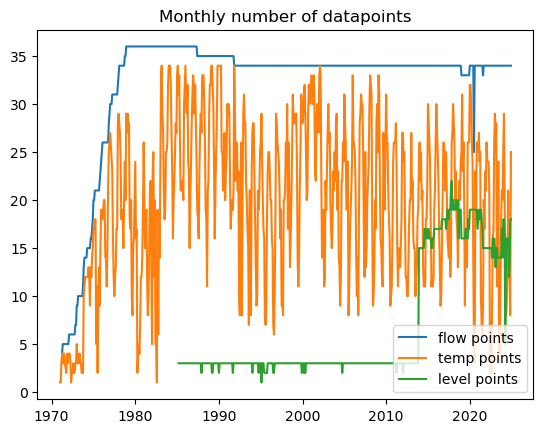

In [9]:
#How many wells measuring each thing do we have?
count_flow = df[(df.typ_sk==1)].groupby([df.ts.dt.year, df.ts.dt.month, df.name])['val'].mean()
count_flow = count_flow.groupby(level=[0, 1]).count()
count_flow.index = pd.to_datetime(pd.DataFrame(count_flow.index.tolist(), columns=['year', 'month']).assign(day=1))

count_temp = df[(df.typ_sk==2)].groupby([df.ts.dt.year, df.ts.dt.month, df.name])['val'].mean()
count_temp = count_temp.groupby(level=[0, 1]).count()
count_temp.index = pd.to_datetime(pd.DataFrame(count_temp.index.tolist(), columns=['year', 'month']).assign(day=1))

count_level = df[(df.typ_sk==5)].groupby([df.ts.dt.year, df.ts.dt.month, df.name])['val'].mean()
count_level = count_level.groupby(level=[0, 1]).count()
count_level.index = pd.to_datetime(pd.DataFrame(count_level.index.tolist(), columns=['year', 'month']).assign(day=1))

plt.plot(count_flow.index, count_flow.values, label='flow points')
plt.plot(count_temp.index, count_temp.values, label='temp points')
plt.plot(count_level.index, count_level.values, label='level points')
plt.legend()
plt.title('Monthly number of datapoints')
plt.show()
plt.close()

# Borehole data

In [10]:
#Import borehole database
borehole_data = pd.read_csv('gisborhola.csv')
#Select relevant columns
borehole_data = borehole_data.loc[:, ('borholunofn', 'x', 'y', 'dypi', 'maxfdypi')]
#Rename to English
borehole_data.rename(columns={'borholunofn': 'name', 'dypi': 'depth', 'maxfdypi': 'casing'}, inplace=True)
#Select only wells in the previous file
borehole_data = borehole_data[borehole_data['name'].isin(df.name.unique())]
borehole_data = borehole_data.sort_values(by=['name'])
#Remove duplicates (?)
borehole_data.drop([3924, 11307, 11928], inplace=True) #remove other MG-01s (???)
#Reset index
borehole_data.reset_index(drop=True, inplace=True)
#Make sure 'depth' are floats (imported with commas)
borehole_data.depth = borehole_data.depth.str.replace(',', '.').astype(float)

borehole_data.shape

(38, 5)

Text(0.5, 1.0, 'Well depths and casings')

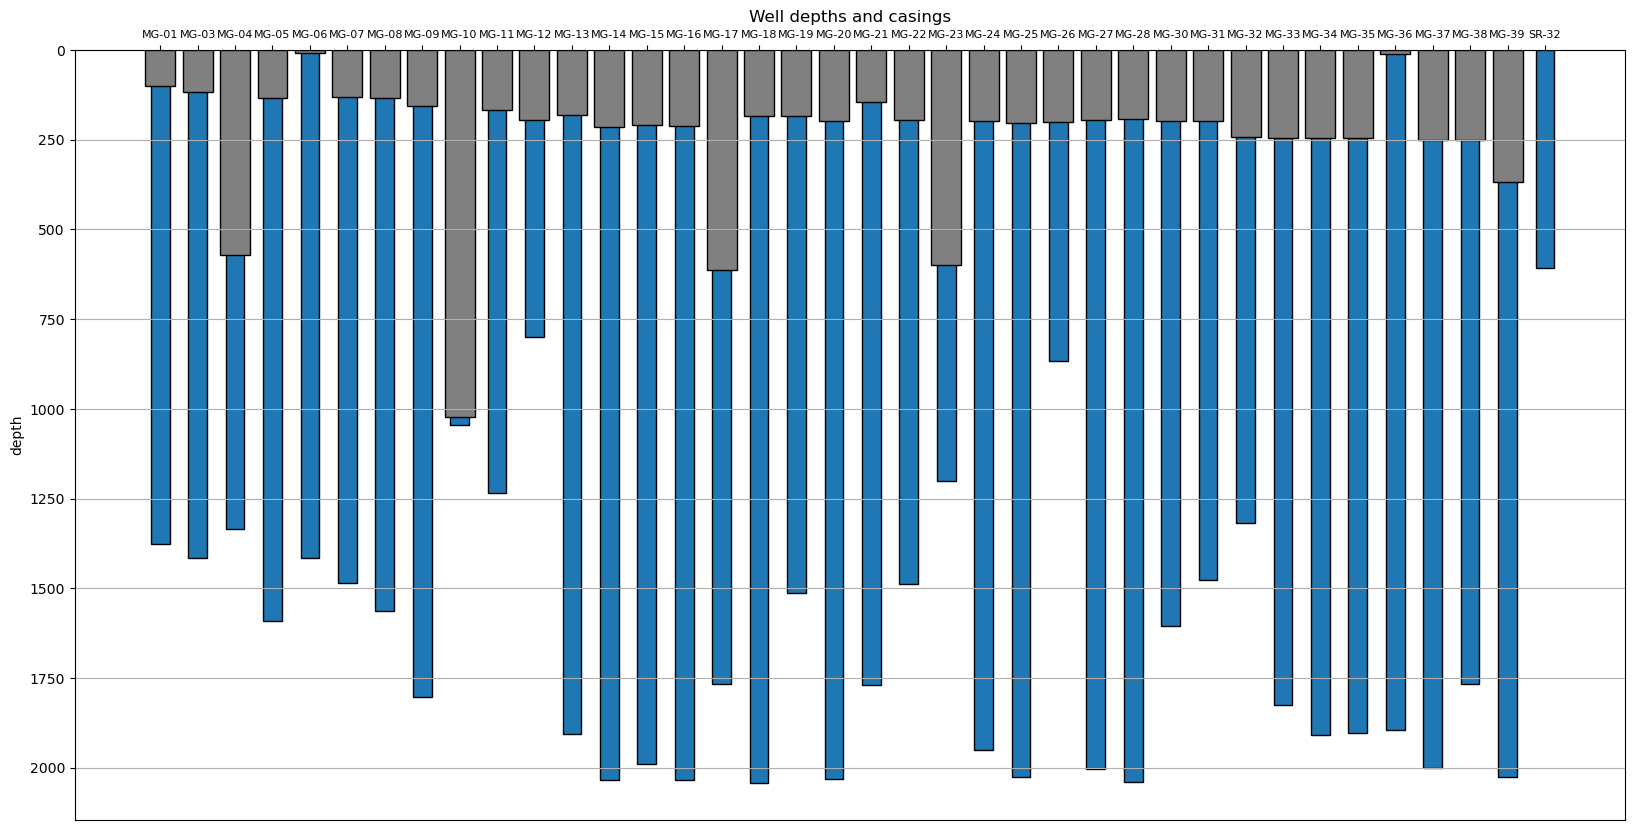

In [11]:
plt.figure(figsize=(20,10))
plt.bar(borehole_data.name, borehole_data.depth, width=0.5, edgecolor='k', color='tab:blue')
plt.bar(borehole_data.name, borehole_data.casing, edgecolor='k', color='gray')
plt.gca().invert_yaxis()
plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.tick_params(axis='x', labelsize=8)
plt.grid(axis='y')
plt.ylabel('depth')
plt.title('Well depths and casings')

In [12]:
print('x :', borehole_data.x.min(), borehole_data.x.max())
print('y :', borehole_data.y.min(), borehole_data.y.max())

x : 370202.8 373898.9
y : 408278.9 411190.2


In [20]:
borehole_data.to_csv("borehole_data.csv", index=False)

# Geographical location

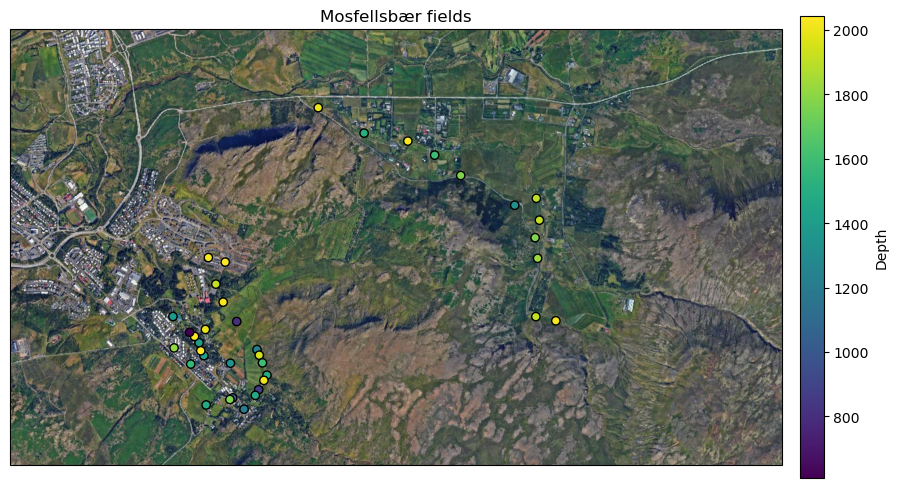

In [13]:
request = cimgt.GoogleTiles(style='satellite') #‘street’, ‘satellite’, ‘terrain’, and ‘only_streets’

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(3057))
ax.set_extent([-21.7, -21.55, 64.15, 64.185], crs=ccrs.PlateCarree())

sc = ax.scatter(borehole_data.x, borehole_data.y, c=borehole_data.depth, edgecolors='k', transform=ccrs.epsg(3057))
cbar = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.02, label='Depth')

ax.add_image(request, 14) 

plt.title('Mosfellsbær fields')
plt.show()
plt.close()

# Top view visualisations

In [14]:
def plot_map(data_type, year, show_wells=True, show_map=False, show_interp = True, show_contours=False, annotate=False):
    #Extract relevant values and arrange in df
    type_dict = {'flow': 1,
                'temp' : 2, 
                'level': 5}
    annual_values = df[(df.typ_sk==type_dict[data_type])].groupby([df.ts.dt.year, df.name])['val'].mean().loc[year, :].reindex(borehole_data.name)
    d = {'name':annual_values.index , 'val': annual_values.values, 'x': borehole_data.x, 'y': borehole_data.y}
    well_data = pd.DataFrame(data=d)
    well_data = well_data.dropna()

    #Create 2D grid for interpolation
    x = np.linspace(min(well_data.x)-500, max(well_data.x)+500, 100)
    y = np.linspace(min(well_data.y)-500, max(well_data.y)+500, 100)
    X, Y = np.meshgrid(x, y) 

    #Different options for interpolating 
    #Z = griddata((well_data.x, well_data.y), well_data.flow, (X, Y), method='cubic') #options are: linear, nearest, cubic
    #or
    #interp = CloughTocher2DInterpolator(list(zip(well_data.x, well_data.y)), well_data.flow)
    #Z = interp(X, Y)
    #or
    points = well_data[["x", "y"]].values  # shape (n, 2)
    values = well_data['val'].values      # shape (n,)
    rbf = RBFInterpolator(points, values, kernel='linear') #options are: linear, thin_plate_spline, cubic, quintic, multiquadric, inverse_multiquadric, inverse_quadratic, gaussian
    grid_points = np.column_stack([X.ravel(), Y.ravel()])
    Z = rbf(grid_points)
    Z = Z.reshape(X.shape)

    #Visualise
    cmap_dict = {
        'flow': 'viridis', 
        'temp': 'coolwarm',
        'level': 'cividis'
    }

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.epsg(3057))
    ax.set_extent([-21.7, -21.55, 64.15, 64.185], crs=ccrs.PlateCarree())
        
    if show_interp == True:
        plot1 = ax.pcolormesh(X, Y, Z, cmap=cmap_dict[data_type])
        cbar1 = plt.colorbar(plot1, ax=ax, shrink=0.5, pad=0.02)
    if show_contours == True:
        plot2 = ax.contour(X, Y, Z, cmap=cmap_dict[data_type])
        cbar2 = plt.colorbar(plot2, ax=ax, shrink=0.5, pad=0.02)
    if show_wells == True: 
        plot3 = ax.scatter(well_data.x, well_data.y, c=well_data.val, cmap=cmap_dict[data_type])
        cbar3 = plt.colorbar(plot3, ax=ax, shrink=0.5, pad=0.02)
    if show_map == True: 
        request = cimgt.GoogleTiles(style='street')
        plot4 = ax.add_image(request, 14)
    if annotate == True: 
        for i, txt in enumerate(borehole_data.name):
            plot5 = ax.annotate(txt, (borehole_data.x[i]-200, borehole_data.y[i]+100))
        
    plt.title(f'{data_type} data: {year}')
    plt.show()
    plt.close()

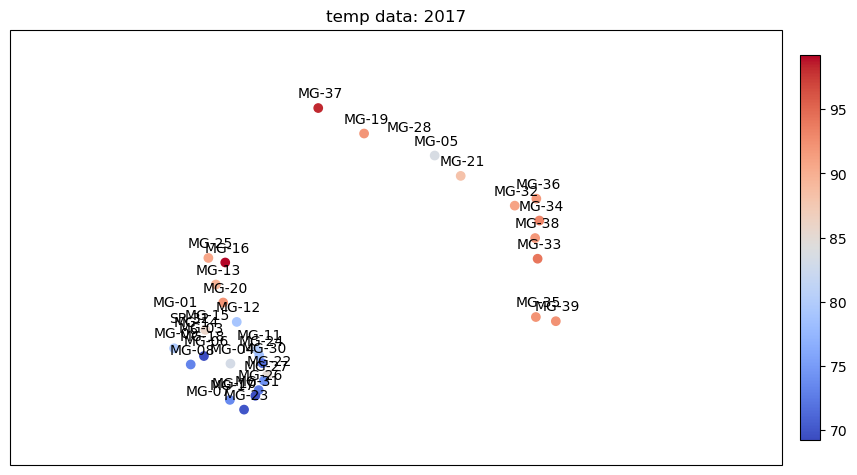

In [15]:
plot_map(data_type='temp', year=2017, show_wells=True, show_map=False, show_interp = False, show_contours=False, annotate=True)

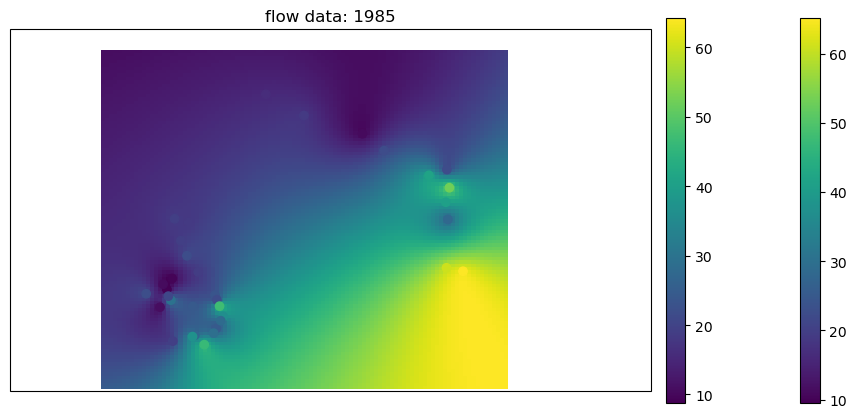

In [16]:
plot_map(data_type='flow', year=1985, show_wells=True, show_map=False, show_interp = True, show_contours=False, annotate=False)

<urlopen error [Errno 8] nodename nor servname provided, or not known>


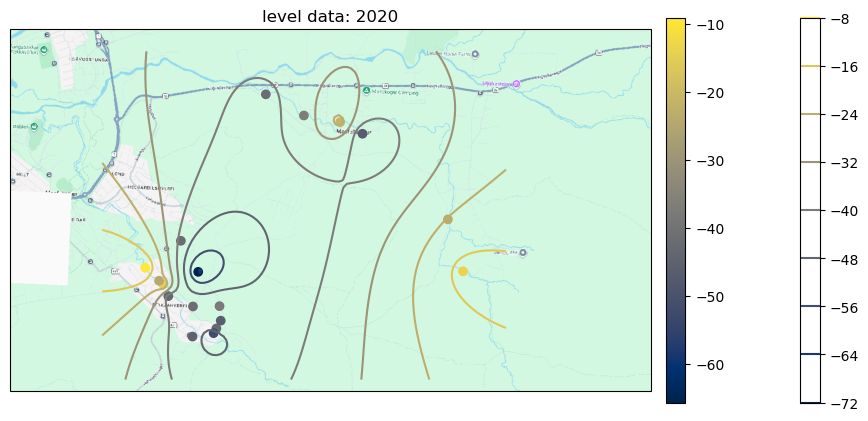

In [17]:
plot_map(data_type='level', year=2020, show_wells=True, show_map=True, show_interp = False, show_contours=True, annotate=False)